In [1]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt
from datasets import *
from sklearn.metrics import recall_score, f1_score, roc_auc_score, accuracy_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
import shap
import reload_shap_plot

In [2]:
# --------------------------
# 新增方法：基于 Z-Score 的检测方法 (ZScore Detector)
# 该方法计算训练数据中各特征的均值与标准差，然后对每个样本计算 Z-score，
# 若任一特征的绝对 Z-score 超过预设阈值，则判定为异常
class ZScoreDetector:
    def __init__(self, feature_len, channel=1, z_threshold=2.0):
        """
        feature_len: 每个通道的特征数量
        channel: 输入通道数
        z_threshold: Z-score 阈值。若任一特征的 Z-score 超过该值，则判定为异常
        """
        self.num_features = channel * feature_len
        self.z_threshold = z_threshold
        self.mean = None
        self.std = None

    def fit(self, x, y=None):
        """
        x: numpy 数组，形状为 (n_samples, channel, feature_len)
        计算训练数据展平后每个特征的均值和标准差，用于标准化
        """
        n_samples = x.shape[0]
        x_flat = x.reshape(n_samples, -1)
        self.mean = np.mean(x_flat, axis=0)
        self.std = np.std(x_flat, axis=0)
        # 防止除零错误
        self.std[self.std == 0] = 1e-6

    def predict(self, x):
        """
        x: numpy 数组，形状为 (n_samples, channel, feature_len)
        返回: numpy 数组，预测结果 (0 or 1)，1 表示样本中任一特征的 Z-score 超过阈值 (异常)
        """
        n_samples = x.shape[0]
        x_flat = x.reshape(n_samples, -1)
        z_scores = np.abs((x_flat - self.mean) / self.std)
        max_z = np.max(z_scores, axis=1)
        predictions = (max_z > self.z_threshold).astype(int)
        return predictions

    def predict_proba(self, x):
        """
        x: numpy 数组，形状为 (n_samples, channel, feature_len)
        返回: numpy 数组，形状为 (n_samples, 2)，每行分别表示属于类别 0 和 1 的概率
        """
        n_samples = x.shape[0]
        x_flat = x.reshape(n_samples, -1)
        z_scores = np.abs((x_flat - self.mean) / self.std)
        max_z = np.max(z_scores, axis=1)
        diff = max_z - self.z_threshold
        p1 = 1 / (1 + np.exp(-diff))
        p0 = 1 - p1
        return np.column_stack((p0, p1))

In [3]:
dataset = BinaryDataset('Node123_loop')
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(20))
feature_names = [f'Bus {i+1}' for i in range(1, dataset.n_buses + 1)]

In [4]:
model = ZScoreDetector(feature_len=dataset.n_buses, channel=1, z_threshold=1.353)

In [5]:
model.fit(train_dataset.dataset.data.numpy(), train_dataset.dataset.labels)

In [6]:
# Get predictions
y_true = test_dataset.dataset.labels[test_dataset.indices]
y_pred = model.predict(test_dataset.dataset.data[test_dataset.indices].numpy())
y_proba = model.predict_proba(test_dataset.dataset.data[test_dataset.indices].numpy())[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_proba)

# Print metrics
print(f'Accuracy: {accuracy}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print(f'AUC: {auc}')

Accuracy: 0.5275
Recall: 0.445
F1 Score: 0.48501362397820164
AUC: 0.4970375


In [7]:
# for z_threshold in np.arange(-3.0, 3.0, 0.001):
#     model.z_threshold = z_threshold
#     y_pred = model.predict(test_dataset.dataset.data[test_dataset.indices].numpy())
#     y_proba = model.predict_proba(test_dataset.dataset.data[test_dataset.indices].numpy())[:, 1]
#     accuracy = accuracy_score(y_true, y_pred)
#     recall = recall_score(y_true, y_pred)
#     f1 = f1_score(y_true, y_pred)
    
#     # Track the best F1 score and corresponding metrics
#     if 'best_acc' not in locals():
#         best_acc = 0
#         best_metrics = {}

#     if accuracy > best_acc:
#         best_acc = accuracy
#         best_metrics = {
#             'f1': f1,
#             'accuracy': accuracy,
#             'recall': recall,
#             'z_threshold': z_threshold
#         }

# print(f"Best F1 Score: {best_metrics['f1']}, Accuracy: {best_metrics['accuracy']}, Recall: {best_metrics['recall']}, Z-Threshold: {best_metrics['z_threshold']}")

# Explain

In [8]:
label_1_samples = []
label_0_samples = []
for data, label in train_dataset:
    if label.item() == 1:  # Filter label 1 samples
        label_1_samples.append(data)  # Convert to NumPy for SHAP
    else: 
        label_0_samples.append(data)

# Convert to NumPy array for SHAP compatibility
label_0_samples = np.array(label_0_samples)
label_1_samples = np.array(label_1_samples)

print(label_0_samples.shape)
print(label_1_samples.shape)

(800, 1, 122)
(800, 1, 122)


In [9]:
# Compute mean background from normal (label 0) samples
background_mean = label_0_samples.mean(0)  # Compute mean across samples
# background_mean = torch.tensor(np.zeros_like(background_mean)+0.1, dtype=torch.float32)  # Use zero mean as background

# Ensure at least (n_buses + 1) samples
n_buses = background_mean.shape[-1]
num_background_samples = n_buses + 1  # Ensure SHAP has enough samples

# Convert to NumPy for SHAP
background = background_mean

""" Check this line of code """
background = np.tile(background, (2, 1))  # Expand background size *2

background.shape

(2, 122)

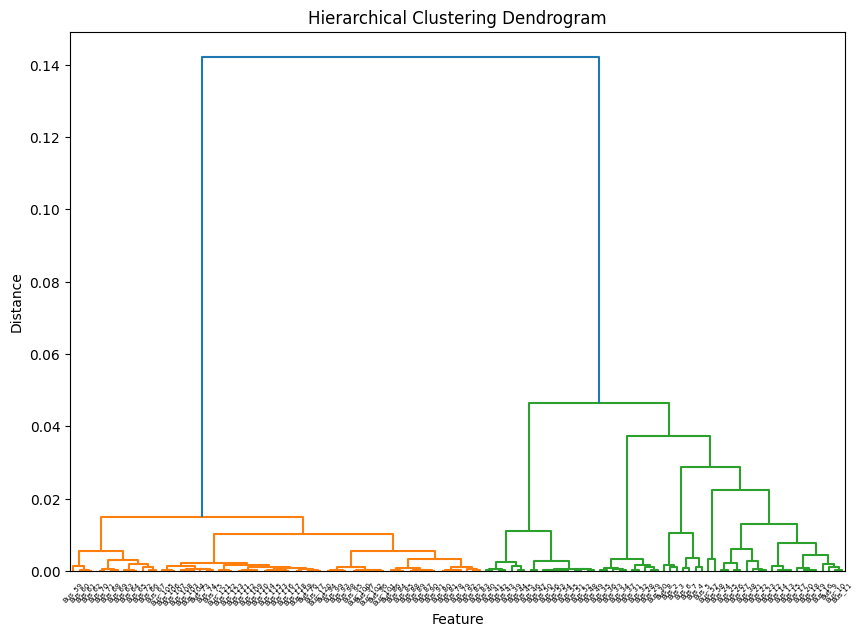

In [10]:
def get_matrix_from_data(data_normal, data_outage):
    # # Combine the two datasets
    # combined_data = pd.concat([data_normal, data_outage])
    combined_data = data_normal
    # combined_data = data_outage

    # Compute the correlation matrix
    corr_matrix = combined_data.corr()

    # Convert the correlation matrix to a distance matrix
    distance_matrix = 1 - corr_matrix

    # Perform hierarchical clustering
    Z = linkage(squareform(distance_matrix), method='average')
    return Z, corr_matrix

Z, corr_matrix = get_matrix_from_data(dataset.data_df, dataset.data_outage_df)

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(Z, labels=corr_matrix.columns, leaf_rotation=45)
# dendrogram(Z, leaf_rotation=45)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Feature')
plt.ylabel('Distance')
plt.show()

In [11]:
instance = label_1_samples[0]
instance.shape

(1, 122)

In [12]:
def model_wrapper(x):
    # Get prediction
    return model.predict_proba(x)[:, 1]

In [13]:
# Initialize SHAP Explainer
masker = shap.maskers.Partition(background)
masker.clustering = Z  # 强制使用你的 partition_tree
explainer = shap.PartitionExplainer(model_wrapper, masker, feature_names=feature_names)

In [14]:
shap_values = explainer(label_1_samples.squeeze())

PartitionExplainer explainer: 801it [00:19, 20.34it/s]                         


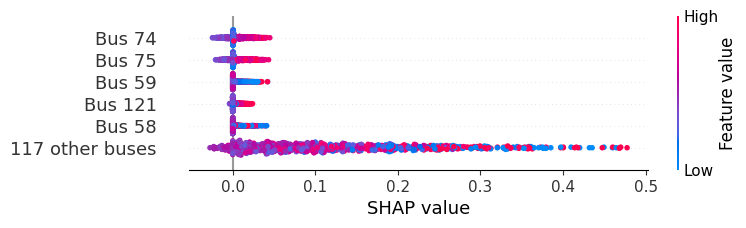

In [15]:
shap.plots.beeswarm(shap_values, max_display=6, plot_size=(7.4, 2))

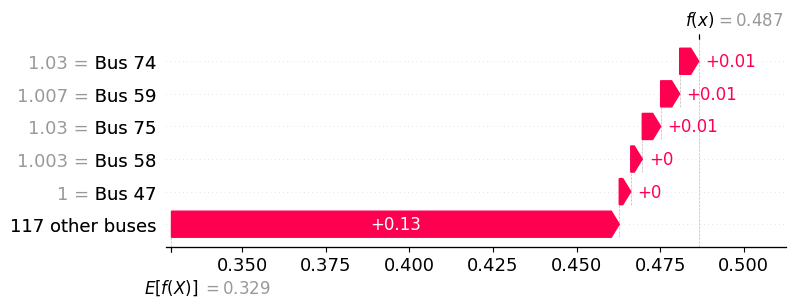

In [16]:
shap.plots.waterfall(shap_values.mean(0), max_display=6)

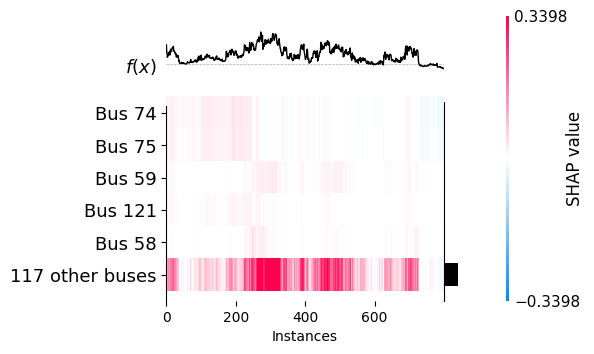

<Axes: xlabel='Instances'>

In [17]:
shap.plots.heatmap(shap_values, max_display=6)

---

In [18]:
explainer = shap.Explainer(model_wrapper, background, feature_names=feature_names)

In [19]:
shap_values = explainer(label_1_samples.squeeze())

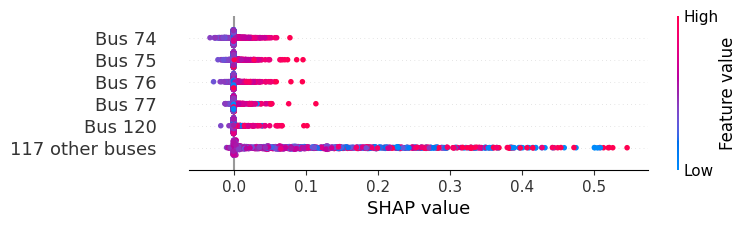

In [20]:
shap.plots.beeswarm(shap_values, max_display=6, plot_size=(7.4, 2))

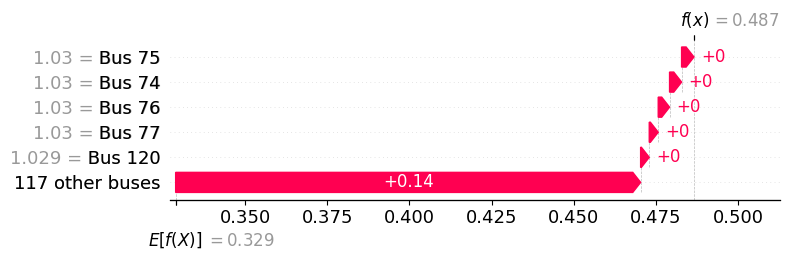

In [21]:
shap.plots.waterfall(shap_values.mean(0), show=False)
plt.tight_layout()
plt.show()

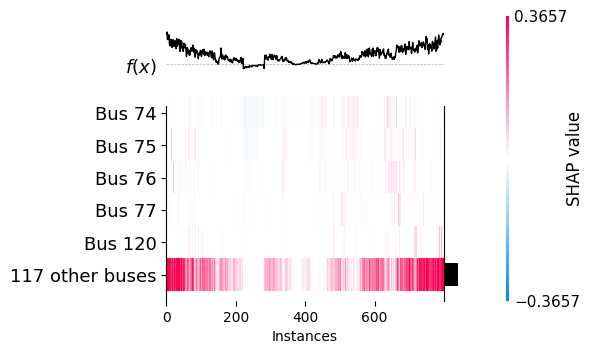

<Axes: xlabel='Instances'>

In [22]:
shap.plots.heatmap(shap_values, max_display=6)